# AI ANALYST LAB

![](../_img/ai_analyst_lab.png)

### A Hands-on Course on AI for Data Analysts
## Review 03: Information Theory

Feedback should be sent to [goran.milovanovic@datakolektiv.com](mailto:goran.milovanovic@datakolektiv.com).

This is a **review notebook**. It steps away from the business cases for one session to introduce a beautiful and surprisingly practical idea: how to **measure information itself** — how much surprise, uncertainty, and shared structure live inside a probability distribution. Everything here is built up gently, from scratch, assuming nothing beyond the probability you met in Review 02.

***
### What we will do today

We build the core of **information theory** one small idea at a time, and we compute every quantity ourselves in a few lines of Python.

| Section | Idea | The one-line intuition |
|---|---|---|
| R3.1 | **Surprisal** | a *rare* event carries *more* information |
| R3.2 | **Shannon entropy** | the *average* surprise of a whole distribution |
| R3.3 | **Maximal entropy & the Diversity Index** | how *uncertain* can a distribution be, on a 0–100% scale |
| R3.4 | **Joint entropy** | the uncertainty of *two* variables together |
| R3.5 | **Conditional entropy** | what's left to learn about one variable *once you know* another |
| R3.6 | **Mutual information** | how much two variables *tell you about each other* |

The method is the one this course always uses: **compute first in Python, then read the number.** No formula is left as an abstraction — each one is turned into a tiny function and tried on a concrete example.

***
### A short history: who was Claude Shannon?

In **1948**, a 32-year-old engineer at Bell Telephone Laboratories named **Claude Elwood Shannon** published a paper titled *"A Mathematical Theory of Communication."* It has been called *the Magna Carta of the Information Age* — because, more or less single-handedly, it created the entire field we are about to explore.

Before Shannon, "information" was a vague, everyday word. After him, it was a **measurable quantity**, with units (**bits**) and laws as firm as those of thermodynamics. Everything that followed — data compression (ZIP files, JPEGs), error-correcting codes, the theoretical limits of every phone line and fibre-optic cable on Earth — traces back to that one paper.

The remarkable thing, for us, is that his central ideas need only a little probability and a logarithm. Let's build them.

***
First, the handful of tools we need. Information theory lives on the **base-2 logarithm** (`np.log2`), because we measure information in *bits*.

In [1]:
# pandas for small tables, numpy for the math, matplotlib for plots.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A clean plotting style for the whole notebook.
plt.rcParams["figure.figsize"] = (8, 5)

print("Ready. We will measure information in bits, using the base-2 logarithm np.log2().")

Ready. We will measure information in bits, using the base-2 logarithm np.log2().


***
## R3.1 Information and probability — *surprisal*

Start with a question that sounds philosophical but has a crisp answer: **what makes a message informative?**

Here is the key insight. A message is informative when it tells you something you did *not* expect. *"The sun rose this morning"* carries almost no information — you were certain of it already. *"It snowed in the Sahara this morning"* carries a great deal — it was wildly improbable. So the information in an event is tied to how **surprising** it is, which is tied to how **improbable** it is.

Let's make that precise with a tiny story. Suppose that, on any given morning, I buy a newspaper with probability $P(\text{newspaper}) = \tfrac{1}{2}$ — a coin flip. Over one week we observe the sequence `1001110` (`1` = bought, `0` = didn't). Because each of the 7 days is an independent 50/50 event, the probability of that exact sequence is $\left(\tfrac{1}{2}\right)^7$:

In [2]:
# Seven independent events, each with probability 1/2.
p_one_day = 1/2
prob_of_sequence = p_one_day ** 7
print("P(the exact 7-day sequence) =", prob_of_sequence, "= 1 / 2**7 =", 1/2**7)

P(the exact 7-day sequence) = 0.0078125 = 1 / 2**7 = 0.0078125


We say this sequence of seven equally-unpredictable events carries **7 bits** of information — one bit per coin-flip day. A **bit** is the amount of information in a single 50/50 choice: the answer to one perfectly balanced yes/no question.

> **A little history — the word "bit."** Shannon needed a name for this unit. His colleague **John W. Tukey** (later famous for the Fast Fourier Transform and the box plot) had suggested contracting *"binary digit"* to **"bit."** Shannon adopted it in the 1948 paper, and the word conquered the world.

How do we get from a probability to a number of bits? With the base-2 logarithm. Notice that $-\log_2\!\left(\tfrac{1}{2^7}\right) = 7$:

In [3]:
# The base-2 logarithm turns "probability" into "bits".
print("-log2(1/2**7) =", -np.log2(1/2**7), "bits")

-log2(1/2**7) = 7.0 bits


This motivates the definition. The **information content** of an event $E$ — also called its **surprisal** or **self-information** — is a quantity that is *large when $P(E)$ is small* and *small when $P(E)$ is large*:

$$I(E) \;=\; \log_2\!\left(\frac{1}{P(E)}\right) \;=\; -\log_2\big(P(E)\big)$$

In one line of Python:

In [4]:
def surprisal(p):
    # Information content, in bits, of an event with probability p.
    return -np.log2(p)

# A 50/50 event carries exactly 1 bit of surprise.
print("surprisal(1/2)  =", surprisal(1/2), "bit")
# A rare event (p = 1/100) carries much more.
print("surprisal(1/100) =", round(surprisal(1/100), 3), "bits")

surprisal(1/2)  = 1.0 bit
surprisal(1/100) = 6.644 bits


Let's *see* the shape of surprisal as the probability sweeps from near-0 to 1. Watch how surprise **shoots up** for improbable events and **falls to zero** for a certainty (an event with $P=1$ carries no information at all — you already knew it would happen).

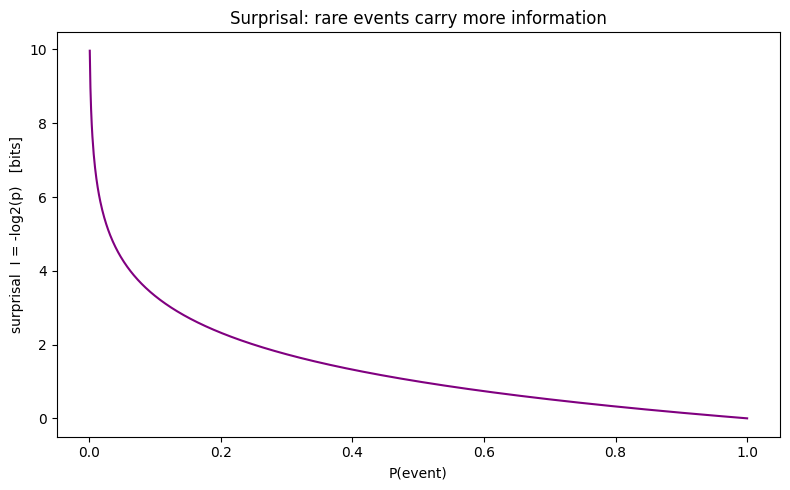

In [5]:
# Plot surprisal across the whole probability range.
p = np.linspace(0.001, 1, 1000)
surp = pd.DataFrame({"probability": p, "surprisal (bits)": surprisal(p)})

surp.plot(x="probability", y="surprisal (bits)", legend=False, color="purple")
plt.title("Surprisal: rare events carry more information")
plt.xlabel("P(event)")
plt.ylabel("surprisal  I = -log2(p)   [bits]")
plt.tight_layout()
plt.show()

***
## R3.2 Shannon entropy — the *average* surprise

Surprisal describes a *single* event. But usually we care about a whole **distribution** of possible events. The natural question becomes: *on average*, how surprising is a random draw from this distribution? That average surprise is **Shannon entropy** — the single most important quantity in information theory.

If a discrete random variable $X$ takes values with probabilities $p_1, p_2, \ldots$, its entropy is the **probability-weighted average of the surprisals**:

$$H(X) \;=\; \sum_i p_i \, I(x_i) \;=\; -\sum_i p_i \log_2 p_i$$

(For a *continuous* variable, described by a density $p(x)$, the sum becomes an integral: $H(X) = -\int p(x)\log_2 p(x)\,dx$ — note the minus sign, exactly as in the discrete case.)

In Python, entropy is a two-line function. The only subtlety is that an impossible outcome ($p=0$) should contribute **zero** surprise, so we simply skip the zero-probability terms:

In [6]:
def entropy(p):
    # Shannon entropy H(X) = -sum p_i log2(p_i), in bits.
    p = np.asarray(p, dtype=float)
    p = p[p > 0]                      # 0 * log2(0) is defined as 0 in information theory
    return float(-np.sum(p * np.log2(p)))

# A fair coin: two equally likely outcomes.
print("entropy of a fair coin [1/2, 1/2] =", entropy([1/2, 1/2]), "bit")

entropy of a fair coin [1/2, 1/2] = 1.0 bit


A fair coin has an entropy of exactly **1 bit** — the most uncertain a single yes/no variable can be. What about a *biased* source? If instead the two outcomes have probabilities $\tfrac{2}{3}$ and $\tfrac{1}{3}$, the entropy is **lower** — the outcome is more predictable, so there is less average surprise:

In [7]:
print("fair      [1/2, 1/2] :", round(entropy([1/2, 1/2]), 4), "bits")
print("biased    [2/3, 1/3] :", round(entropy([2/3, 1/3]), 4), "bits")
print("very sure [0.99, 0.01]:", round(entropy([0.99, 0.01]), 4), "bits")

fair      [1/2, 1/2] : 1.0 bits
biased    [2/3, 1/3] : 0.9183 bits
very sure [0.99, 0.01]: 0.0808 bits


**A business reading of the same idea.** Imagine a churn model that outputs, for a given customer, the probability they will *churn* vs *stay*. A confident prediction and an uncertain one have very different entropies — and entropy is a clean, single-number way to say *"how unsure is this prediction?"* Compare a confident case with a coin-flip case:

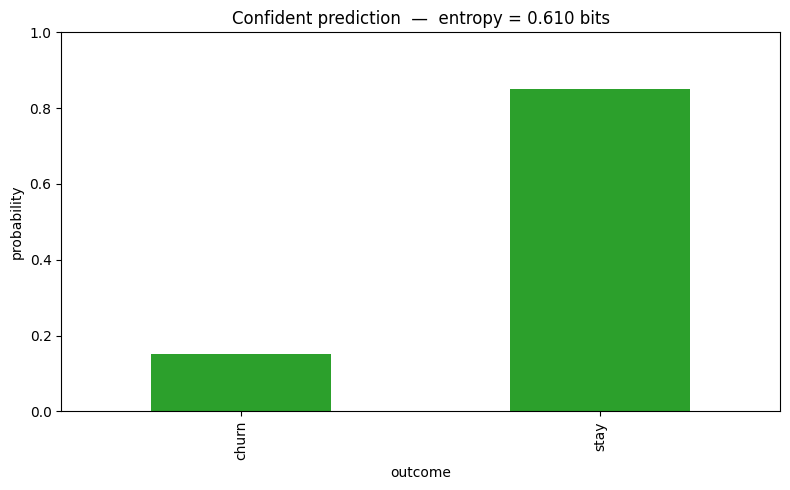

In [8]:
# A confident prediction: 15% churn / 85% stay.
confident = pd.DataFrame({"outcome": ["churn", "stay"], "probability": [0.15, 0.85]})
confident.plot.bar(x="outcome", y="probability", legend=False, color="#2ca02c")
plt.title(f"Confident prediction  —  entropy = {entropy(confident['probability']):.3f} bits")
plt.ylabel("probability"); plt.ylim(0, 1); plt.tight_layout(); plt.show()

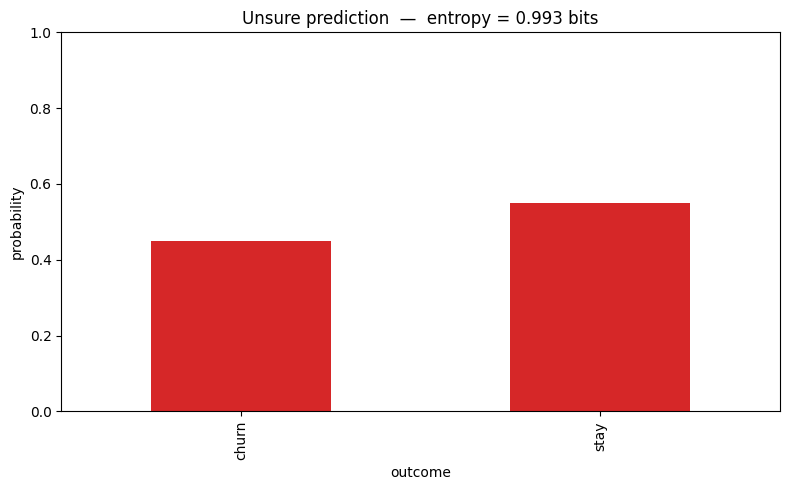

In [9]:
# An almost coin-flip prediction: 45% churn / 55% stay.
uncertain = pd.DataFrame({"outcome": ["churn", "stay"], "probability": [0.45, 0.55]})
uncertain.plot.bar(x="outcome", y="probability", legend=False, color="#d62728")
plt.title(f"Unsure prediction  —  entropy = {entropy(uncertain['probability']):.3f} bits")
plt.ylabel("probability"); plt.ylim(0, 1); plt.tight_layout(); plt.show()

The near-balanced prediction has **much higher entropy** — the model is close to a coin flip, and entropy quantifies exactly that hesitation.

Now the famous picture. Take a coin whose bias $P(\text{Heads})$ we can dial from 0 to 1, and plot its entropy. It is **zero** at the extremes (a two-headed or two-tailed coin holds no surprise) and rises to its **maximum of 1 bit** exactly when the coin is fair:

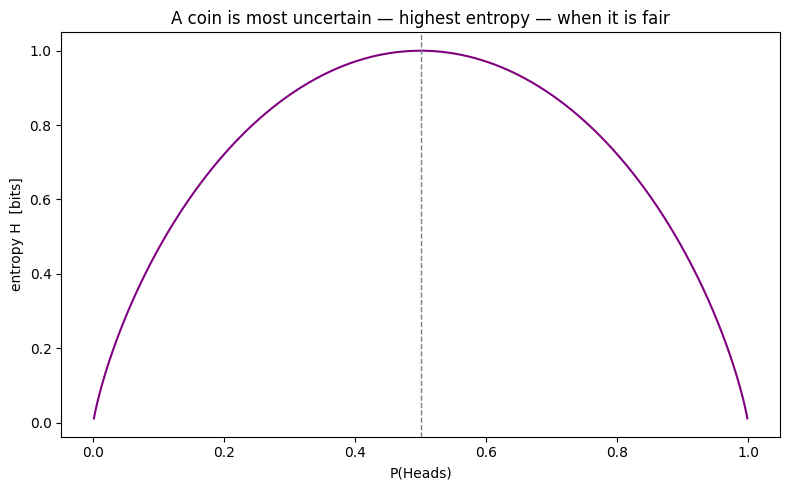

In [10]:
# Entropy of a biased coin as its P(Heads) sweeps from 0 to 1.
p = np.linspace(0.001, 0.999, 1000)
coin_entropy = [entropy([ph, 1 - ph]) for ph in p]
curve = pd.DataFrame({"P(Heads)": p, "entropy (bits)": coin_entropy})

curve.plot(x="P(Heads)", y="entropy (bits)", legend=False, color="purple")
plt.axvline(0.5, ls="--", color="grey", lw=1)
plt.title("A coin is most uncertain — highest entropy — when it is fair")
plt.xlabel("P(Heads)"); plt.ylabel("entropy H  [bits]")
plt.tight_layout(); plt.show()

> **A little history — why "entropy"?** Shannon's formula $-\sum p\log p$ is identical in form to a quantity from 19th-century thermodynamics. The story goes that when Shannon asked the mathematician **John von Neumann** what to call it, von Neumann replied: *"You should call it entropy, for two reasons. In the first place your uncertainty function has been used in statistical mechanics under that name, so it already has a name. In the second place, and more important, no one really knows what entropy really is, so in a debate you will always have the advantage."*

***
## R3.3 Maximal entropy and the Shannon Diversity Index

The coin plot hints at a general law. If a variable has $N$ possible outcomes, **how uncertain can it possibly be?** The answer: entropy is largest when *all outcomes are equally likely*, and that maximum is

$$H_{\max} = \log_2 N$$

For a coin ($N=2$) that ceiling is $\log_2 2 = 1$ bit; for a die ($N=6$) it is $\log_2 6 \approx 2.585$ bits:

In [11]:
print("max entropy of a coin (N=2):", np.log2(2), "bit")
print("max entropy of a die  (N=6):", round(np.log2(6), 4), "bits")

max entropy of a coin (N=2): 1.0 bit
max entropy of a die  (N=6): 2.585 bits


Let's watch a three-outcome distribution climb toward its ceiling of $\log_2 3 \approx 1.585$ bits as it flattens from lopsided to perfectly even:

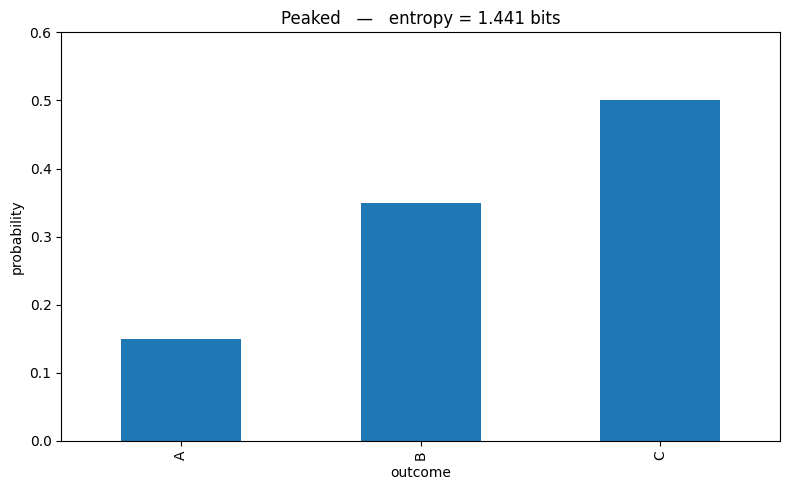

In [12]:
# Three distributions over the same 3 outcomes, from peaked to uniform.
def show_distribution(probs, title):
    d = pd.DataFrame({"outcome": ["A", "B", "C"], "probability": probs})
    d.plot.bar(x="outcome", y="probability", legend=False, color="#1f77b4")
    plt.title(f"{title}   —   entropy = {entropy(probs):.3f} bits")
    plt.ylabel("probability"); plt.ylim(0, 0.6); plt.tight_layout(); plt.show()

show_distribution([0.15, 0.35, 0.50], "Peaked")

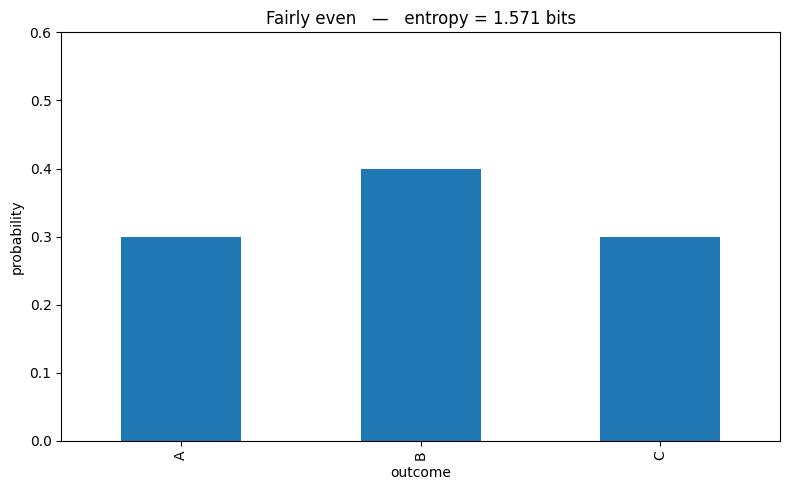

In [13]:
show_distribution([0.30, 0.40, 0.30], "Fairly even")

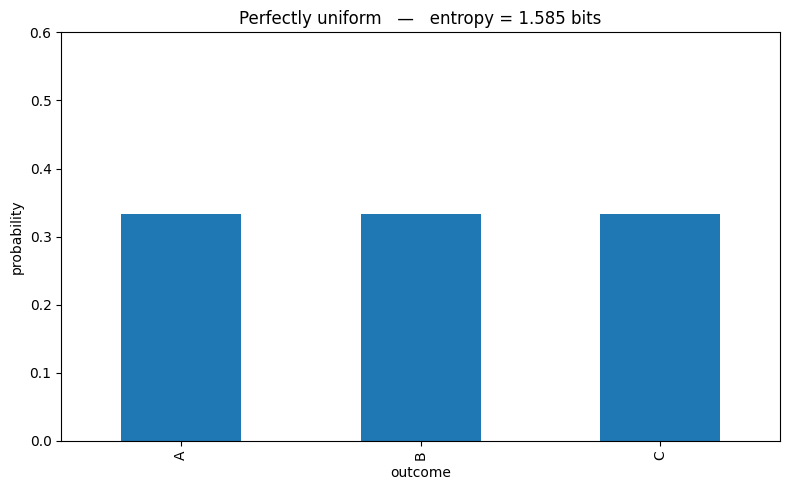

In [14]:
show_distribution([1/3, 1/3, 1/3], "Perfectly uniform")

In [15]:
# The uniform case hits the theoretical ceiling exactly.
print("entropy of uniform 3-outcome :", round(entropy([1/3, 1/3, 1/3]), 4), "bits")
print("theoretical max  log2(3)     :", round(np.log2(3), 4), "bits")

entropy of uniform 3-outcome : 1.585 bits
theoretical max  log2(3)     : 1.585 bits


Because the ceiling $\log_2 N$ depends on the number of outcomes, raw entropy is awkward to compare across variables of different sizes. The fix is to **divide by the maximum**, giving the **Shannon Diversity Index** (also called Shannon *equitability*):

$$E_H = \frac{H(X)}{\log_2 N}$$

This rescales any distribution's uncertainty onto a clean **0 to 1** scale: 0 means "completely certain", 1 means "maximally uncertain / perfectly even".

In [16]:
def diversity(p):
    # Shannon Diversity Index: entropy rescaled to [0, 1].
    p = np.asarray(p, dtype=float)
    return entropy(p) / np.log2(len(p))

print("diversity of peaked   [0.15, 0.35, 0.50] :", round(diversity([0.15, 0.35, 0.50]), 3))
print("diversity of uniform  [1/3, 1/3, 1/3]    :", round(diversity([1/3, 1/3, 1/3]), 3))

diversity of peaked   [0.15, 0.35, 0.50] : 0.909
diversity of uniform  [1/3, 1/3, 1/3]    : 1.0


**A business use of the Diversity Index.** Suppose a segmentation model predicts, for a customer, a probability distribution over three segments — say **Value-Seekers (A)**, **Premium (B)**, and **Occasional (C)**. Multiplying the diversity index by 100 turns it into a plain-English *"percent uncertainty"* of that prediction. A model that is fairly torn between segments scores high; a confident model scores low:

In [17]:
# Prediction 1: the model leans to segment B but isn't sure.
print("segments [A=.2, B=.7, C=.1]  -> uncertainty:", round(diversity([.2, .7, .1]) * 100, 1), "%")
# Prediction 2: much more confident about A.
print("segments [A=.95, B=.04, C=.01] -> uncertainty:", round(diversity([.95, .04, .01]) * 100, 1), "%")
# Prediction 3: almost certain about A.
print("segments [A=.99, B=.005, C=.005] -> uncertainty:", round(diversity([.99, .005, .005]) * 100, 1), "%")

segments [A=.2, B=.7, C=.1]  -> uncertainty: 73.0 %
segments [A=.95, B=.04, C=.01] -> uncertainty: 20.3 %
segments [A=.99, B=.005, C=.005] -> uncertainty: 5.7 %


As the prediction concentrates on one segment, the uncertainty percentage collapses toward zero — a tidy, model-agnostic way to flag *"this customer's segment is a coin-toss; treat the prediction with caution."*

***
## R3.4 Joint entropy — two variables together

So far, one variable at a time. Real analysis is about **relationships** between variables, so we now bring in a second one. Consider a small marketing dataset: every customer arrived through a **Channel** (paid *Ads* or *Organic* search) and either **Purchased** or did not. Here are the counts:

In [18]:
# Counts of customers cross-classified by Channel x Outcome.
counts = pd.DataFrame({
    "Channel":   ["Ads", "Organic"],
    "Purchased": [45, 27],
    "Not":       [17, 58],
})
print(counts)

   Channel  Purchased  Not
0      Ads         45   17
1  Organic         27   58


To do information theory we need **probabilities**, not counts, so we divide every cell by the grand total. This gives the **joint distribution** $p(x, y)$ — the probability of each (Channel, Outcome) combination:

In [19]:
n = counts[["Purchased", "Not"]].to_numpy().sum()
joint = counts.copy()
joint[["Purchased", "Not"]] = counts[["Purchased", "Not"]] / n
print(joint)
print("\nsum of all joint probabilities =", round(joint[["Purchased", "Not"]].to_numpy().sum(), 6))

   Channel  Purchased       Not
0      Ads   0.306122  0.115646
1  Organic   0.183673  0.394558

sum of all joint probabilities = 1.0


The **joint entropy** measures the total uncertainty of the *pair* $(X, Y)$ — how surprised we are, on average, by a full (Channel, Outcome) observation. The formula is the same "$-\sum p\log_2 p$" as before, now summed over every cell of the table:

$$H(X, Y) = -\sum_x \sum_y p(x, y)\, \log_2 p(x, y)$$

In [20]:
def joint_entropy(p_xy):
    # H(X,Y) = -sum over all cells of p(x,y) log2 p(x,y).
    p = np.asarray(p_xy, dtype=float)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

p_xy = joint[["Purchased", "Not"]].to_numpy()
print("Joint entropy H(Channel, Outcome) =", round(joint_entropy(p_xy), 4), "bits")

Joint entropy H(Channel, Outcome) = 1.8611 bits


There is one elegant special case worth seeing. If two variables are **independent** — knowing one tells you nothing about the other — then their joint entropy is exactly the **sum** of their separate entropies:

$$H(X, Y) = H(X) + H(Y) \qquad \text{(when } X \text{ and } Y \text{ are independent)}$$

Let's build a deliberately independent table (every Outcome equally likely regardless of Channel) and check that the identity holds:

In [21]:
# An independent table: Outcome does NOT depend on Channel.
indep_counts = np.array([[45, 45],    # Ads:     Purchased, Not
                         [25, 25]])    # Organic: Purchased, Not
indep = indep_counts / indep_counts.sum()

h_xy = joint_entropy(indep)
h_x  = entropy(indep.sum(axis=1))     # marginal over Channel (row sums)
h_y  = entropy(indep.sum(axis=0))     # marginal over Outcome (column sums)

print("H(X,Y)      =", round(h_xy, 4))
print("H(X) + H(Y) =", round(h_x + h_y, 4))
print("difference  =", round(h_xy - (h_x + h_y), 10), " (zero, as the theory promises)")

H(X,Y)      = 1.9403
H(X) + H(Y) = 1.9403
difference  = 0.0  (zero, as the theory promises)


***
## R3.5 Conditional entropy — what's left to learn

Now the more interesting, *dependent* case. Return to our real Channel × Outcome table (where the channels clearly differ). **Conditional entropy** asks: *once I already know the Channel, how much uncertainty about the Outcome remains?*

First, a one-line reminder of **conditional probability** from Review 02 — the probability of $Y$ *given* that we know $X$:

$$P(Y \mid X) = \frac{P(X \cap Y)}{P(X)}$$

For our table, the probability that a customer *Purchased given they came from Ads* is the Ads-and-Purchased cell divided by the total Ads probability:

In [22]:
# Back to the real (dependent) joint distribution.
p_xy = joint[["Purchased", "Not"]].to_numpy()   # rows = Channel (Ads, Organic), cols = Outcome
p_channel = p_xy.sum(axis=1)                     # P(Channel): marginal over Outcome

# P(Purchased | Ads) = P(Ads and Purchased) / P(Ads)
p_purch_and_ads = p_xy[0, 0]
p_ads = p_channel[0]
print("P(Purchased | Ads)     =", round(p_purch_and_ads / p_ads, 3))

# P(Purchased | Organic)
print("P(Purchased | Organic) =", round(p_xy[1, 0] / p_channel[1], 3))

P(Purchased | Ads)     = 0.726
P(Purchased | Organic) = 0.318


The two numbers differ substantially — Ads visitors buy far more often — so Channel clearly carries information about Outcome. **Conditional entropy** $H(Y \mid X)$ packages this into a single number: the average remaining uncertainty about $Y$ across all the values of $X$, each weighted by how often it occurs:

$$H(Y \mid X) = -\sum_x \sum_y p(x, y)\, \log_2 p(y \mid x), \qquad p(y \mid x) = \frac{p(x, y)}{p(x)}$$

In [23]:
def conditional_entropy(p_xy, p_x):
    # H(Y|X): remaining uncertainty in Y once X is known.
    p_xy = np.asarray(p_xy, dtype=float)
    p_x  = np.asarray(p_x,  dtype=float)
    p_y_if_x = p_xy / p_x[:, None]        # divide EACH ROW (a value of X) by its own marginal
    mask = p_xy > 0
    return float(-np.sum(p_xy[mask] * np.log2(p_y_if_x[mask])))

h_cond = conditional_entropy(p_xy, p_channel)
print("H(Outcome | Channel) =", round(h_cond, 4), "bits")

H(Outcome | Channel) = 0.8789 bits


Conditional entropy has a lovely relationship with joint entropy — the **chain rule**. The uncertainty of the pair equals the uncertainty of $X$ plus whatever uncertainty about $Y$ is *left over* after $X$ is known:

$$H(X, Y) = H(X) + H(Y \mid X) \qquad\Longleftrightarrow\qquad H(Y \mid X) = H(X, Y) - H(X)$$

Let's confirm the two sides agree — to the last decimal:

In [24]:
h_joint   = joint_entropy(p_xy)
h_channel = entropy(p_channel)

print("H(Outcome | Channel)  computed directly :", round(h_cond, 6))
print("H(X,Y) - H(Channel)   via the chain rule:", round(h_joint - h_channel, 6))
print("difference                              :", round((h_joint - h_channel) - h_cond, 12))

H(Outcome | Channel)  computed directly : 0.878866
H(X,Y) - H(Channel)   via the chain rule: 0.878866
difference                              : 0.0


They match exactly. In plain words: **conditional entropy $H(Y \mid X)$ is the information still in $Y$ that is *not* already explained by $X$.**

***
## R3.6 Mutual information — how much two variables share

We can finally answer the question every analyst really cares about: **how much does knowing one variable tell us about another?** That shared information is **mutual information**, $I(X, Y)$.

The most intuitive definition compares "the uncertainty of the two variables *separately*" against "their uncertainty *together*". If they share structure, the whole is less uncertain than the sum of its parts, and the difference is exactly what they share:

$$I(X, Y) = H(X) + H(Y) - H(X, Y)$$

In [25]:
h_outcome = entropy(p_xy.sum(axis=0))   # H(Outcome): marginal over Channel

mi = h_channel + h_outcome - h_joint
print("H(Channel)          =", round(h_channel, 4))
print("H(Outcome)          =", round(h_outcome, 4))
print("H(Channel, Outcome) =", round(h_joint, 4))
print("-" * 40)
print("Mutual information I(Channel; Outcome) =", round(mi, 4), "bits")

H(Channel)          = 0.9823
H(Outcome)          = 0.9997
H(Channel, Outcome) = 1.8611
----------------------------------------
Mutual information I(Channel; Outcome) = 0.1208 bits


That positive number is the payoff: knowing a customer's acquisition channel removes about that many bits of uncertainty about whether they will purchase. Two facts make mutual information especially useful:

- It is **symmetric**: $I(X, Y) = I(Y, X)$ — the information is *shared*, so it doesn't matter which variable you "know first".
- It is **zero exactly when the two variables are independent** — no shared information at all.

Mutual information can also be written in terms of conditional entropy, $I(X, Y) = H(Y) - H(Y \mid X)$ — "the uncertainty in $Y$, minus the part that survives after learning $X$." Let's confirm both formulas give the same answer, and also invoke the fully general form $I(X,Y) = H(X,Y) - H(X\mid Y) - H(Y\mid X)$:

In [26]:
# Second formula: I(X,Y) = H(Y) - H(Y|X).
print("I via  H(Outcome) - H(Outcome|Channel) =", round(h_outcome - h_cond, 4))

# Third (fully general) form, using BOTH conditional entropies.
def mutual_information(h_xy, h_x_given_y, h_y_given_x):
    # I(X,Y) = H(X,Y) - H(X|Y) - H(Y|X)
    return h_xy - h_x_given_y - h_y_given_x

h_x_given_y = conditional_entropy(p_xy.T, p_outcome := p_xy.sum(axis=0))   # H(Channel | Outcome)
print("I via  H(X,Y) - H(X|Y) - H(Y|X)        =",
      round(mutual_information(h_joint, h_x_given_y, h_cond), 4))

I via  H(Outcome) - H(Outcome|Channel) = 0.1208
I via  H(X,Y) - H(X|Y) - H(Y|X)        = 0.1208


All three formulas agree — a reassuring sign that our entropy machinery is internally consistent.

Finally, one more idea that peers *inside* mutual information. Mutual information is an average; the thing being averaged is the **Pointwise Mutual Information (PMI)** of a single pair of outcomes:

$$\text{pmi}(x, y) = \log_2 \frac{p(x, y)}{p(x)\,p(y)}$$

It measures the surprise of seeing two *specific* outcomes **together**, compared with what we'd expect if they were independent. Positive PMI means the pair co-occurs *more* than chance would predict; negative means *less*. Let's read off the PMI for each Channel–Outcome combination:

In [27]:
p_out = p_xy.sum(axis=0)     # P(Outcome)
labels = [("Ads", "Purchased"), ("Ads", "Not"), ("Organic", "Purchased"), ("Organic", "Not")]
idx    = [(0, 0), (0, 1), (1, 0), (1, 1)]

for (ch, oc), (i, j) in zip(labels, idx):
    pmi = np.log2(p_xy[i, j] / (p_channel[i] * p_out[j]))
    arrow = "more often than chance" if pmi > 0 else "less often than chance"
    print(f"pmi({ch:<7}, {oc:<9}) = {pmi:+.3f} bits   ({arrow})")

pmi(Ads    , Purchased) = +0.567 bits   (more often than chance)
pmi(Ads    , Not      ) = -0.896 bits   (less often than chance)
pmi(Organic, Purchased) = -0.625 bits   (less often than chance)
pmi(Organic, Not      ) = +0.419 bits   (more often than chance)


The signs tell the marketing story at a glance: *Ads & Purchased* light up positive (they co-occur more than independence would predict), while *Ads & Not* is negative. Mutual information is simply the average of these pointwise surprises, weighted by how often each pair actually occurs.

***
## R3.7 Recap — and where information shows up

In one short notebook we built the whole core of information theory, each quantity as a few lines of Python:

| Quantity | Question it answers | Formula |
|---|---|---|
| **Surprisal** $I(E)$ | How informative is *one* event? | $-\log_2 p$ |
| **Entropy** $H(X)$ | How uncertain is *one* variable? | $-\sum p\log_2 p$ |
| **Diversity index** $E_H$ | ...on a 0–100% scale | $H(X)/\log_2 N$ |
| **Joint entropy** $H(X,Y)$ | How uncertain are *two* together? | $-\sum\sum p\log_2 p$ |
| **Conditional entropy** $H(Y\mid X)$ | What's left in $Y$ once $X$ is known? | $H(X,Y) - H(X)$ |
| **Mutual information** $I(X,Y)$ | How much do they *share*? | $H(X)+H(Y)-H(X,Y)$ |

These ideas are not just elegant — they are everywhere. **Entropy** is the theoretical limit of data compression (it is why a ZIP file can only shrink a file so far). **Mutual information** is a general, assumption-free measure of association between variables — it detects *any* kind of dependence, not just the straight-line kind that ordinary correlation sees. And Shannon's **channel capacity**, built from these same quantities, sets the ultimate speed limit of every communication link ever engineered.

> **A last word on Claude Shannon.** He was as playful as he was brilliant. He rode a unicycle down the halls of Bell Labs *while juggling*; he built a mechanical mouse ("Theseus") that could learn a maze, and a deadpan "Ultimate Machine" whose only function was to switch itself off. The field he founded in a single 1948 paper now underlies every megabyte you will ever send or store. Not a bad return on one good idea — measured, appropriately, in bits.

<hr>

![](../_img/DK_Logo_White_150.png)

DataKolektiv, 2026.

[hello@datakolektiv.com](mailto:hello@datakolektiv.com)

<font size=1>License: [GPLv3](../LICENSE). This Notebook is free software: you can redistribute it and/or modify it under the terms of the GNU General Public License as published by the Free Software Foundation, either version 3 of the License, or (at your option) any later version. This Notebook is distributed in the hope that it will be useful, but WITHOUT ANY WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU General Public License for more details.</font>